
# Notebook poprawiony pod Colab / Python 3.12+

Ta wersja **nie wiesza się na pobieraniu BERT-a**, bo domyślnie działa w trybie lokalnym.

## Co się zmieniło
- domyślnie **nie pobiera HerBERT/BERT z Hugging Face**,
- działa bez wcześniejszych plików modeli,
- sama generuje mały zbiór demo, jeśli nie ma `emocje_20000.csv`,
- zapisuje wyniki końcowe do plików,
- ma opcjonalny tryb online, jeśli chcesz jednak użyć modelu z HF.

## Najważniejsza zasada
Na zajęcia i szybkie demo uruchamiaj w pierwszej kolejności tryb lokalny.  
Tryb HF włączaj dopiero wtedy, gdy Colab działa stabilnie i chcesz pokazać fine-tuning modelu pretrenowanego.


In [ ]:

# --- instalacja zależności do Colaba / Pythona 3.12 ---
# Uruchom tę komórkę tylko raz po otwarciu notebooka.
%pip -q install "tensorflow>=2.20,<2.21" "torch>=2.2" "scikit-learn>=1.4" "pandas>=2.2" "numpy>=1.26" "matplotlib>=3.8"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.


In [ ]:

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["OMP_NUM_THREADS"] = "1"

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [ ]:

CSV_PATH = "emocje_20000.csv"

EMOTION_TEMPLATES = {
    "anger": [
        "Jestem wściekły na tę decyzję.",
        "To mnie doprowadza do szału.",
        "Mam dość tego chaosu i kłamstw.",
        "Ta sytuacja mnie potwornie irytuje.",
        "Nie mogę znieść takiego traktowania.",
    ],
    "disgust": [
        "To jest obrzydliwe i odpychające.",
        "Aż mnie skręca z obrzydzenia.",
        "Nie mogę na to patrzeć.",
        "To budzi we mnie wstręt.",
        "To było wyjątkowo odrażające.",
    ],
    "fear": [
        "Boję się, że wszystko zaraz się zawali.",
        "Czuję silny lęk przed tym, co będzie dalej.",
        "Mam w sobie niepokój i drżenie.",
        "Serce bije mi szybciej ze strachu.",
        "To mnie naprawdę przeraża.",
    ],
    "joy": [
        "Jestem dziś naprawdę szczęśliwy.",
        "Rozpiera mnie radość i energia.",
        "To wspaniała wiadomość, aż się uśmiecham.",
        "Mam świetny humor i dużo optymizmu.",
        "Czuję czystą radość.",
    ],
    "sadness": [
        "Jest mi bardzo smutno po tej wiadomości.",
        "Czuję pustkę i przygnębienie.",
        "Łzy same napływają mi do oczu.",
        "To wszystko budzi we mnie głęboki smutek.",
        "Mam dziś ciężkie serce.",
    ],
    "surprise": [
        "Ale niespodzianka, kompletnie się tego nie spodziewałem.",
        "To było bardzo zaskakujące.",
        "Jestem w szoku po tym zwrocie akcji.",
        "Nie mogę uwierzyć, że to się wydarzyło.",
        "To całkowicie mnie zaskoczyło.",
    ],
}

MODIFIERS = [
    " dzisiaj.", " rano.", " wieczorem.", " po tej rozmowie.",
    " po spotkaniu.", " w pracy.", " w domu.", " i nie wiem co powiedzieć."
]

def ensure_demo_csv(csv_path=CSV_PATH, train_per_label=40, val_per_label=10, test_per_label=10):
    path = Path(csv_path)
    if path.exists():
        print(f"Używam istniejącego pliku: {path}")
        return path

    rows = []
    label_to_id = {label: idx for idx, label in enumerate(EMOTION_TEMPLATES.keys())}

    for label, templates in EMOTION_TEMPLATES.items():
        for split, n in [("train", train_per_label), ("val", val_per_label), ("test", test_per_label)]:
            for _ in range(n):
                text = random.choice(templates) + random.choice(MODIFIERS)
                rows.append({
                    "text": text,
                    "label": label,
                    "label_id": label_to_id[label],
                    "split": split,
                })

    df_demo = pd.DataFrame(rows)
    df_demo.to_csv(path, index=False)
    print(f"Wygenerowano plik demo: {path}")
    return path

ensure_demo_csv()


Używam istniejącego pliku: emocje_20000.csv


PosixPath('emocje_20000.csv')

In [ ]:

df = pd.read_csv(CSV_PATH)
required_cols = {"text", "label", "label_id", "split"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Brakuje kolumn: {missing}")

df = df.dropna(subset=["text", "label", "label_id", "split"]).copy()
df["text"] = df["text"].astype(str)
df["label_id"] = df["label_id"].astype(int)

label_to_id = (
    df[["label", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
    .set_index("label")['label_id']
    .to_dict()
)
id_to_label = {int(v): k for k, v in label_to_id.items()}
label_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

print(df.head())
print("\nRozkład splitów:")
print(df["split"].value_counts())
print("\nMapowanie:", label_to_id)


                                                text    label  label_id  split
0  Wieczorem bardzo boję się gdy myślę o przyszło...     fear         2  train
1  W pracy naprawdę jestem szczęśliwy, gdy dostał...      joy         3    val
2  W tej chwili bardzo jestem zirytowana gdy ktoś...    anger         0  train
3  W domu ja bardzo jestem szczęśliwa gdy dostałe...      joy         3  train
4  Wieczorem wyjątkowo jestem zniesmaczona kiedy ...  disgust         1  train

Rozkład splitów:
split
train    14000
val       3000
test      3000
Name: count, dtype: int64

Mapowanie: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


## Lokalny transformer zamiast pobierania BERT-a

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers

TRANSFORMER_OUTPUT_DIR = Path("tiny_transformer_output")
TRANSFORMER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_TOKENS = 2000
SEQ_LEN = 24
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 64
BATCH_SIZE = 16
EPOCHS = 6

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
)
vectorizer.adapt(train_df["text"].values)

@tf.keras.utils.register_keras_serializable()
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "maxlen": self.maxlen,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config

vocab_size = len(vectorizer.get_vocabulary())
num_classes = len(label_names)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
x = TokenAndPositionEmbedding(SEQ_LEN, vocab_size, EMBED_DIM)(x)
x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

transformer_model = tf.keras.Model(inputs=inputs, outputs=outputs)
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = transformer_model.fit(
    train_df["text"].values,
    train_df["label_id"].values,
    validation_data=(val_df["text"].values, val_df["label_id"].values),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
)

transformer_probs = transformer_model.predict(test_df["text"].values, verbose=0)
transformer_pred = np.argmax(transformer_probs, axis=1)
y_true = test_df["label_id"].values

transformer_metrics = {
    "accuracy": float(accuracy_score(y_true, transformer_pred)),
    "f1_macro": float(f1_score(y_true, transformer_pred, average="macro")),
    "f1_weighted": float(f1_score(y_true, transformer_pred, average="weighted")),
}

print("\nMetryki transformera:")
print(transformer_metrics)

report = classification_report(y_true, transformer_pred, target_names=label_names, digits=4)
print("\nClassification report:\n")
print(report)

cm = confusion_matrix(y_true, transformer_pred)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
cm_df


Epoch 1/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9555 - loss: 0.1514 - val_accuracy: 1.0000 - val_loss: 1.0028e-04
Epoch 2/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9976 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 4.7547e-05
Epoch 3/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9999 - loss: 5.4617e-04 - val_accuracy: 1.0000 - val_loss: 8.9805e-06
Epoch 4/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 1.0000 - loss: 2.3399e-04 - val_accuracy: 1.0000 - val_loss: 2.7002e-06
Epoch 5/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 1.0000 - loss: 1.2309e-04 - val_accuracy: 1.0000 - val_loss: 9.5983e-07
Epoch 6/6
875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 1.0000 - loss: 1.0777e-04 - val_accuracy: 1.0000 - val_loss: 4.0034e-07

Metryki transformera:
{'accuracy': 1.0, 'f1_macro': 1.0, 'f1_weighted': 1.0}

Classification report:

              precision    recall  f1-score   support

       anger     1.0000    1.

,anger,disgust,fear,joy,sadness,surprise
anger,500,0,0,0,0,0
disgust,0,500,0,0,0,0
fear,0,0,500,0,0,0
joy,0,0,0,500,0,0
sadness,0,0,0,0,500,0
surprise,0,0,0,0,0,500


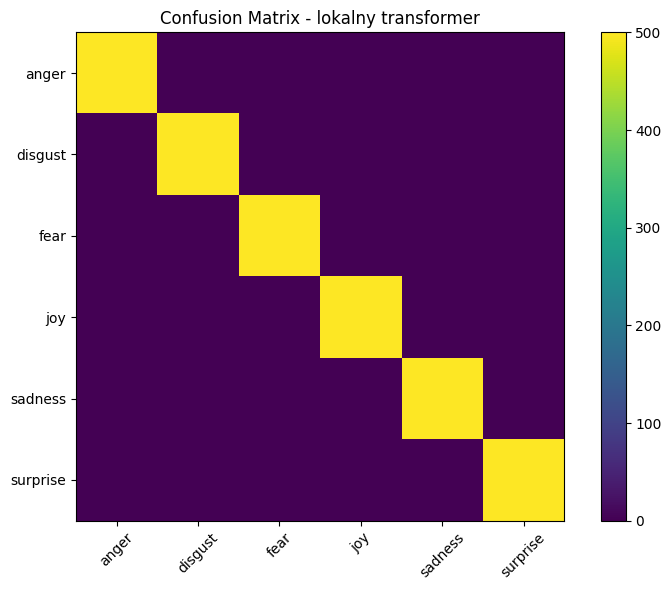

Zapisano wyniki do: /content/tiny_transformer_output


In [ ]:

transformer_model.save(TRANSFORMER_OUTPUT_DIR / "model_transformer.keras")

with open(TRANSFORMER_OUTPUT_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label_to_id": label_to_id, "id_to_label": id_to_label}, f, ensure_ascii=False, indent=2)

with open(TRANSFORMER_OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(transformer_metrics, f, ensure_ascii=False, indent=2)

with open(TRANSFORMER_OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)
    f.write("\n\nConfusion matrix:\n")
    f.write(np.array2string(cm))

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - lokalny transformer")
plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.yticks(range(len(label_names)), label_names)
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Zapisano wyniki do: {TRANSFORMER_OUTPUT_DIR.resolve()}")


In [ ]:
examples = [
    "Jestem dziś naprawdę szczęśliwy i pełen energii.",
    "To jest obrzydliwe i nie mogę na to patrzeć.",
    "Boję się, że wszystko zaraz się zawali.",
    "Jestem wściekły na tę decyzję.",
    "Czuję ogromny smutek po tej wiadomości.",
    "Ale niespodzianka, kompletnie się tego nie spodziewałem!",
]

probs = transformer_model.predict(tf.constant(examples, dtype=tf.string), verbose=0)
preds = np.argmax(probs, axis=1)

pd.DataFrame({
    "text": examples,
    "predicted_label": [id_to_label[int(i)] for i in preds],
    "confidence": [float(np.max(row)) for row in probs],
})

,text,predicted_label,confidence
0,Jestem dziś naprawdę szczęśliwy i pełen energii.,joy,0.999584
1,To jest obrzydliwe i nie mogę na to patrzeć.,disgust,0.999994
2,"Boję się, że wszystko zaraz się zawali.",anger,0.999895
3,Jestem wściekły na tę decyzję.,anger,0.999995
4,Czuję ogromny smutek po tej wiadomości.,surprise,0.721709
5,"Ale niespodzianka, kompletnie się tego nie spo...",surprise,0.999999



## Opcjonalnie: tryb online z Hugging Face

Ta sekcja jest **wyłączona domyślnie**. Włącz ją tylko wtedy, gdy naprawdę chcesz użyć modelu pretrenowanego i masz stabilny internet.

Najbezpieczniejszy wariant na Colabie:
- najpierw uruchom lokalny notebook do końca,
- potem dopiero ustaw `USE_HF_PRETRAINED = True`,
- najlepiej zacznij od lżejszego modelu wielojęzycznego, a nie od cięższego HerBERT-a.


In [ ]:

USE_HF_PRETRAINED = False
HF_MODEL_NAME = "distilbert/distilbert-base-multilingual-cased"

if USE_HF_PRETRAINED:
    raise RuntimeError(
        "Ten notebook domyślnie działa lokalnie, żeby nie wisiał na pobieraniu modelu. "
        "Jeśli chcesz użyć HF, odpal osobną wersję fine-tuningową dopiero po sprawdzeniu internetu w Colabie."
    )
else:
    print("Tryb HF wyłączony. To jest zamierzone.")
